# Interactive self-consistent GW for graphene

Construct the graphene model and its full GW iteration directly from QAssemble objects. The companion `g0w0.ipynb` stops after one update; here $G$, $P$, $W$, and the self-energy are updated until the same criteria used by QAssemble's GW solver are satisfied. All quantities remain available in memory for inspection between cells.

In [1]:
from contextlib import redirect_stdout
from io import StringIO

import matplotlib.pyplot as plt
import numpy as np

from QAssemble import Crystal, DLR, G, G0, H, H0, Mixing, P, SigF, SigGWC, SigH, SigStc, V, W, Z

KGrid = [25, 25, 1]
T = 2000.0
CutOff = 100.0
MIX = 0.1
MAX_ITER = 2000
CONSTANT_W = 1.0
KPath = [[0, 0, 0], [2 / 3, 1 / 3, 0], [1 / 2, 1 / 2, 0], [0, 0, 0]]
KLabel = [r'$\Gamma$', 'K', 'M', r'$\Gamma$']
NKPath = 121

## 1. Define the graphene Hamiltonian and interaction

These are the same lattice, hopping, $U=2$ eV, and $V=0.2$ eV used in `g0w0.ipynb`. Edit the dictionaries or the numerical settings above, then rerun from this point to try a different model.

In [2]:
Crystal_Input = {
    "RVec": [[1, 0, 0], [0.5, 0.866, 0], [0, 0, 1]],
    "SOC": False,
    "CorF": "F",
    "Basis": [[[0.33333, 0.33333, 0], 1], [[0.66667, 0.66667, 0], 1]],
    "NSpin": 1,
    "NElec": 2,
    "KGrid": KGrid,
}

Hopping = {
    ((0, 0), (1, 0)): {
        1.0: [[0, 0, 0], [-1, 0, 0], [0, -1, 0]],
    }
}
Onsite = {0: {(0, 0): 0.0, (1, 0): 0.0}}

Local_Interaction = {
    "Parameter": "SlaterKanamori",
    "option": {
        1: {"l": 0, "value": [2.0, 0.0, 0.0], "orbitals": [0]},
        2: {"l": 0, "value": [2.0, 0.0, 0.0], "orbitals": [0]},
    },
}
NonLocal_Interaction = {
    ((0, 0), (1, 0)): {
        0.20: [[0, 0, 0], [-1, 0, 0], [0, -1, 0]],
    }
}

## 2. Build the bare objects

`Crystal`, `DLR`, `H0`, `G0`, and `V` are constructed explicitly. Their arrays are available as `h0.k`, `g0.kf`, and `v.k`. The constructor log is kept in `solver_log` if you want to inspect details.

In [3]:
solver_log = StringIO()
with redirect_stdout(solver_log):
    crystal = Crystal(Crystal_Input)
    dlr = DLR({'T': T, 'cutoff': CutOff})
    h0 = H0(crystal, hopping=Hopping, onsite=Onsite)
    g0 = G0(crystal, dlr, h0.k)
    v = V(crystal, orboption=Local_Interaction, intamp=NonLocal_Interaction)
    gold = G(crystal, dlr, g0.kf)

print(f'H0 {h0.k.shape}; G0 {g0.kf.shape}; V {v.k.shape}')
print(f'Initial chemical potential: {gold.mu:.10f} eV')

H0 (2, 2, 1, 625); G0 (2, 2, 1, 625, 40); V (2, 2, 1, 1, 625)
Initial chemical potential: 0.0000000000 eV


## 3. Compose one GW update

The function below contains the full update in physical order: $G_n \to (\Sigma^H_n,\Sigma^F_n,P_n) \to W_n \to \Sigma^C_n \to G_{n+1}$. `Mixing` is applied to $P$ and $\Sigma^C$, as in the package's GW loop. The function calls the same numerical object methods; it does not call `Run` or `GWApproximation`.

In [4]:
p_mixer = Mixing()
sigma_mixer = Mixing()

def gw_step(iteration, old_green, old_p=None, old_sigma=None):
    with redirect_stdout(solver_log):
        sigma_h = SigH(crystal, occ=old_green.occ, v=v.k)
        sigma_f = SigF(crystal, occr=old_green.occr, v=v.r)
        polarization = P(crystal, dlr, old_green.rt)
        polarization.kf = p_mixer(
            iter=iteration, mix=MIX, Fnew=polarization.kf,
            Fold=np.zeros_like(polarization.kf) if old_p is None else old_p,
        )
        screened = W(crystal, dlr, polarization.kf, v, c=CONSTANT_W)
        sigma_c = SigGWC(crystal, dlr, old_green.rt, screened.crt)
        sigma_c.kf = sigma_mixer(
            iter=iteration, mix=MIX, Fnew=sigma_c.kf,
            Fold=np.zeros_like(sigma_c.kf) if old_sigma is None else old_sigma,
        )
        new_green = G(
            crystal, dlr, g0.kf,
            sigh=sigma_h.k, sigf=sigma_f.k, siggwc=sigma_c.kf,
        )
    return new_green, polarization, screened, sigma_h, sigma_f, sigma_c

Run **one** update first. Inspect `polarization.kf`, `screened.kf`, `sigma_c.kf`, or `gnew.kf` here before continuing. Rerun the setup and mixing cells to restart from the bare Green function.

In [5]:
gnew, polarization, screened, sigma_h, sigma_f, sigma_c = gw_step(1, gold)
dg = float(np.max(np.abs(gnew.kf - gold.kf)))
dw = float(np.max(np.abs(screened.kf)))  # W_0 = 0 in the package loop
dmu = abs(gnew.mu - gold.mu)
history = [{'iteration': 1, 'mu': gnew.mu, 'dG': dg, 'dW': dw, 'dmu': dmu}]
print(f'1: mu={gnew.mu:.10f}, |ΔG|∞={dg:.3e}, |ΔW|∞={dw:.3e}, |Δmu|={dmu:.3e}')
print(f'P {polarization.kf.shape}; W {screened.kf.shape}; Sigma_C {sigma_c.kf.shape}')

1: mu=1.6000001735, |ΔG|∞=9.941e-02, |ΔW|∞=2.000e+00, |Δmu|=1.600e+00
P (2, 2, 1, 1, 625, 49); W (2, 2, 1, 1, 625, 49); Sigma_C (2, 2, 1, 625, 40)


## 4. Continue to self-consistency

Each pass calls the same `gw_step` above. The stopping rule matches the package GW loop: after the Pulay history fills, require $\|\Delta G\|_\infty\leq10^{-6}$, $\|\Delta W\|_\infty\leq10^{-4}$, and $|\Delta\mu|\leq0.01$ eV. The scalar history stays in `history`; the latest full objects remain available by name.

In [6]:
converged = False
for iteration in range(2, MAX_ITER + 1):
    gold = gnew
    old_p, old_sigma, old_w = polarization.kf, sigma_c.kf, screened.kf
    gnew, polarization, screened, sigma_h, sigma_f, sigma_c = gw_step(
        iteration, gold, old_p, old_sigma,
    )
    dg = float(np.max(np.abs(gnew.kf - gold.kf)))
    dw = float(np.max(np.abs(screened.kf - old_w)))
    dmu = abs(gnew.mu - gold.mu)
    history.append({'iteration': iteration, 'mu': gnew.mu, 'dG': dg, 'dW': dw, 'dmu': dmu})
    converged = (
        iteration > p_mixer.npulay and dg <= 1e-6
        and dw <= 1e-4 and dmu <= 0.01
    )
    if iteration <= 5 or iteration % 5 == 0 or converged:
        print(f'{iteration}: mu={gnew.mu:.10f}, |ΔG|∞={dg:.3e}, '
              f'|ΔW|∞={dw:.3e}, |Δmu|={dmu:.3e}')
    if converged:
        break

assert converged, f'GW did not converge within {MAX_ITER} iterations'
green = gnew
occupancy_trace = float(np.trace(green.occ[:, :, 0]).real)
assert abs(occupancy_trace - crystal.nume) < 1e-6
print(f'Converged after {iteration} iterations: mu={green.mu:.10f} eV, '
      f'occupation trace={occupancy_trace:.10f} (target {crystal.nume:.10f})')

2: mu=1.6000000455, |ΔG|∞=1.247e-03, |ΔW|∞=4.820e-03, |Δmu|=1.280e-07
3: mu=1.6000000333, |ΔG|∞=8.553e-04, |ΔW|∞=3.725e-02, |Δmu|=1.221e-08
4: mu=1.6000001703, |ΔG|∞=7.694e-03, |ΔW|∞=5.961e-03, |Δmu|=1.371e-07
5: mu=1.6000002180, |ΔG|∞=2.667e-04, |ΔW|∞=4.809e-04, |Δmu|=4.764e-08
10: mu=1.6000001074, |ΔG|∞=1.152e-05, |ΔW|∞=1.739e-03, |Δmu|=6.932e-08
15: mu=1.6000002328, |ΔG|∞=3.541e-05, |ΔW|∞=5.498e-05, |Δmu|=1.799e-08
20: mu=1.6000002422, |ΔG|∞=1.993e-05, |ΔW|∞=4.728e-06, |Δmu|=2.563e-09
25: mu=1.6000002359, |ΔG|∞=1.721e-06, |ΔW|∞=1.316e-05, |Δmu|=1.434e-08
30: mu=1.6000000348, |ΔG|∞=9.010e-06, |ΔW|∞=2.420e-05, |Δmu|=9.956e-08
31: mu=1.6000000849, |ΔG|∞=7.843e-07, |ΔW|∞=1.311e-05, |Δmu|=5.016e-08
Converged after 31 iterations: mu=1.6000000849 eV, occupation trace=1.0000000075 (target 1.0000000000)


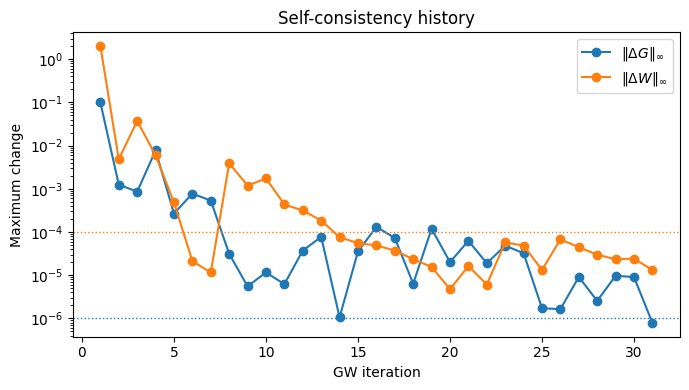

In [7]:
steps = np.array([row['iteration'] for row in history])
fig, ax = plt.subplots(figsize=(7, 4))
for key, label in [('dG', r'$\|\Delta G\|_\infty$'),
                   ('dW', r'$\|\Delta W\|_\infty$')]:
    ax.semilogy(steps, [row[key] for row in history], marker='o', label=label)
ax.axhline(1e-6, color='C0', linestyle=':', linewidth=1)
ax.axhline(1e-4, color='C1', linestyle=':', linewidth=1)
ax.set(xlabel='GW iteration', ylabel='Maximum change', title='Self-consistency history')
ax.legend()
fig.tight_layout()
plt.show()

## 5. Bands from the converged self-energy

Use the first positive DLR Matsubara node to construct the same static quasiparticle approximation as in `g0w0.ipynb`, now with the **converged** $\Sigma^C$, $\Sigma^H$, $\Sigma^F$, and chemical potential. This band construction is controlled near the Fermi level.

In [8]:
omega_dlr = np.asarray(dlr.omega)
i0 = int(np.searchsorted(omega_dlr, 0.0))
assert np.isclose(omega_dlr[i0], np.pi / dlr.beta)
sigma_c_positive = np.asfortranarray(sigma_c.kf[..., i0:])
with redirect_stdout(solver_log):
    z = Z(crystal, sigmac=sigma_c_positive, beta=dlr.beta)
    sigma_static = SigStc(crystal, sigmac=sigma_c_positive, beta=dlr.beta)
    h_qp = H(
        crystal, h0=h0.k, beta=dlr.beta, mu=green.mu,
        sigh=sigma_h.k, sigf=sigma_f.k,
        sigmac=sigma_static.k, z=z.k,
    )
z_eigenvalues = np.linalg.eigvalsh(np.moveaxis(z.k, (0, 1), (-2, -1))).real
print(f'Z eigenvalue range: {z_eigenvalues.min():.4f}–{z_eigenvalues.max():.4f}')

Z eigenvalue range: 0.9478–0.9502


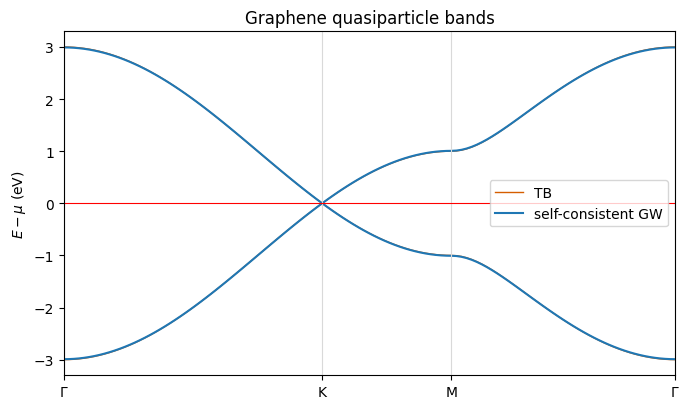

In [10]:
crystal.Kpath(kpath=KPath, nk=NKPath)
h0_path = h0.R2KArb(h0.K2R(h0.k), crystal.kpath)
h_qp_path = h0.R2KArb(h0.K2R(h_qp.k), crystal.kpath)
tb_bands = np.linalg.eigvalsh(np.moveaxis(h0_path[:, :, 0, :], -1, 0)).T
qp_bands = np.linalg.eigvalsh(np.moveaxis(h_qp_path[:, :, 0, :], -1, 0)).T
assert tb_bands.shape == qp_bands.shape == (2, NKPath)

fig, ax = plt.subplots(figsize=(7, 4.2))
for band in range(tb_bands.shape[0]):
    ax.plot(crystal.kdist, tb_bands[band], color="#D55E00",
            linewidth=1.0,
            label='TB' if band == 0 else None)
    ax.plot(crystal.kdist, qp_bands[band], color='C0',
            label='self-consistent GW' if band == 0 else None)
for node in crystal.knode:
    ax.axvline(node, color='0.85', linewidth=0.8)
ax.axhline(0, color='red', linewidth=0.8)
ax.set(xlim=(crystal.knode[0], crystal.knode[-1]), xticks=crystal.knode,
       ylabel=r'$E-\mu$ (eV)', title='Graphene quasiparticle bands')
ax.set_xticklabels(KLabel)
ax.legend()
fig.tight_layout()
plt.show()